<a href="https://colab.research.google.com/github/pranavm716/Reaction-Playground/blob/main/Reaction_Playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!pip install rdkit-pypi

In [ ]:
from __future__ import print_function
# import rdkit components
from rdkit import rdBase
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors

# use IPythonConsole for pretty drawings
from rdkit.Chem.Draw import IPythonConsole

## The next line is commented out 
### because GitHub does not render svg's embedded in notebooks
# IPythonConsole.ipython_useSVG=True
IPythonConsole.ipython_useSVG=False

# for flattening tuples and lists
from itertools import chain

from google.colab import drive
drive.mount('/content/drive')

from PIL import Image, ImageTk
import pdb

Mounted at /content/drive


In [ ]:
mol = Chem.MolFromSmiles('NC')
water = Chem.MolFromSmiles('O')
molecules = [mol]

Draw.MolsToGridImage(molecules, molsPerRow=4)
test = 3
# ogtup = ((9, ),
#  (1, 2, 2),
#  (2, 1, 2, 3),
#  (1, 2, 3))

# t = tuple(set([tuple(set(x)) for x in ogtup]))

l = "jkdl.sdfjkl>"
s = l.split(".")
print(s)

['jkdl', 'sdfjkl>']


In [ ]:
class Reaction: 
  def __init__(self, name, rxn_list, description, num_reactants) -> None:
    self.name = name
    self.rxn_list = rxn_list
    self.description = description
    self.num_reactants = num_reactants
  
  def get_name(self):
    return self.name
  
  def get_description(self):
    return self.description

  def get_rxn_list(self):
    return self.rxn_list

  def get_num_reactants(self):
    return self.num_reactants
  
  def get_smarts(self):
    return [AllChem.ReactionToSmarts(rxn) for rxn in self.rxn_list]

  def __str__(self):
    return f"{self.name}: {self.get_smarts()}"

def display_2d_mol_tuple(tup):
  for scenario in tup:
    ps = list(scenario)
    display(Draw.MolsToGridImage(ps, molsPerRow=len(ps)))
    print()

def generate_unique_products(products):
  smiles = tuple(tuple(Chem.MolToSmiles(s) for s in scenarios) for scenarios in products)
  unique_smiles = tuple(set([tuple(set(x)) for x in smiles]))
  return tuple(tuple(Chem.MolFromSmiles(s) for s in scenarios) for scenarios in unique_smiles) 

def generate_single_step_product(startMol, rxn, optional_reactants = tuple()):
  products = tuple()
  for r in rxn.get_rxn_list():
    products += r.RunReactants((startMol, ) + optional_reactants)

  return generate_unique_products(products)

def generate_multi_step_product_recursion(startMol, rxn, products):
  # display(Draw.MolToImage(startMol))
  single_step_product = generate_single_step_product(startMol, rxn)
  if not len(single_step_product):
    return (startMol, )
  else:
    # display_2d_mol_tuple(single_step_product)
    for scenario in single_step_product:
      for p in scenario:
        products += generate_multi_step_product_recursion(p, rxn, products)

    return products

def generate_multi_step_product(startMol, rxn):
  products = generate_multi_step_product_recursion(startMol, rxn, tuple())
  return generate_unique_products((products, ))

# Reads all reactions from file
def preprocess():
  f = open("/content/drive/My Drive/Side Projects/Cheminformatics/Reactions.txt", "r")
  lines = [l.strip() for l in f.readlines()]
  f.close()
  all_rxns = []
  i = 0
  while i < len(lines):
    rxn_name = lines[i]
    i += 1
    rxn_list = []
    while lines[i].startswith("^"):
      rxn_list.append(AllChem.ReactionFromSmarts(lines[i][1:]))
      i += 1
    reactants_side = lines[i-1].index(">")
    num_reactants = lines[i-1][1:reactants_side].count(".") + 1
    rxn_desc = lines[i]
    i += 2

    all_rxns.append(Reaction(rxn_name, rxn_list, rxn_desc, num_reactants))
  
  return all_rxns

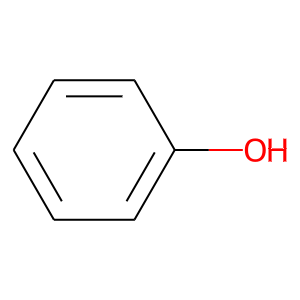

Smiles of molecule: Oc1ccccc1

Compatible reactions are listed below. Choose a reaction:

[1] Fischer esterification
Esterifies a carboxylic acid by reacting it with an alcohol.

[q] Quit

1
Enter the SMILES of the carboxylic acid: C(C)CC(=O)O

You entered:


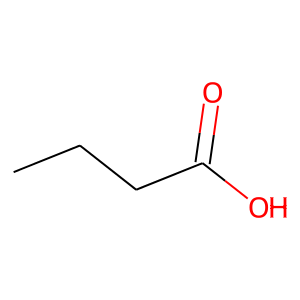



1 x 1


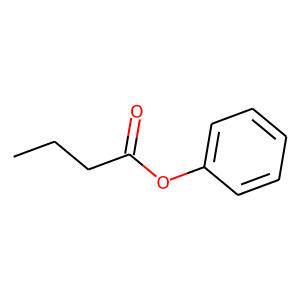

Smiles of molecule: CCCC(=O)Oc1ccccc1

Compatible reactions are listed below. Choose a reaction:

[1] Hydrolysis of esters, amides, and nitriles
Hydrolizes esters/amides/nitriles into carboxylic acids.

[2] LiAlH4 (lithium aluminum hydride) reduction of aldehyes, ketones, esters, carboxylic acids, amides, and nitriles
Converts aldehydes, esters, and carboxylic acids to primary alcohols; ketones to secondary alcohols; and amides/nitriles to amines (TODO: methyl cases).

[b] Back

[q] Quit

q


In [ ]:
all_rxns = preprocess()

# startSMILES = 'CC(=O)OC1=CC=CC=C1C(=O)O' # aspirin
# startSMILES = 'CCOC(=O)c1ccccc1' # ethyl butanoate
# startSMILES = 'O=C(OCC(COC(=O)C1CC1)OC(=O)C2CCC2)C3CCCC3'
startSMILES = 'Oc1ccccc1'
# startSMILES = input("Enter the SMILES of the starting molecule: ")
startMol = Chem.MolFromSmiles(startSMILES)

# targetYN = input("Would you like to input a target molecule? (y/n): ")
# targetMol = None
# if targetYN == "y":
#   targetSMILES = input("Enter the SMILES of the target molecule: ")
#   targetMol = Chem.MolFromSmiles(targetSMILES)
targetMol = Chem.MolFromSmiles("CCC=O")

num_steps = 2
multi_step_react_mode = True
history = [startMol]

choice = None
while not choice == "q":
  display(Draw.MolToImage(startMol))
  print(f"Smiles of molecule: {Chem.MolToSmiles(startMol)}")

  # Finds out which reactions are valid for the current molecule 
  possible_reactions = []
  for obj in all_rxns:
    # print(obj.get_name())
    possible_scenarios = []
    for rxn in obj.get_rxn_list():
      rxn_smarts = AllChem.ReactionToSmarts(rxn)
      reactants_side = rxn_smarts[:rxn_smarts.index(">")]
      reactants_side = reactants_side.split(".")
      reaction_match = []
      for mol in reactants_side:
        reaction_match.append(startMol.HasSubstructMatch(Chem.MolFromSmarts(mol)))
      possible_scenarios.append(any(reaction_match))
    # print(possible_scenarios)
    possible_reactions.append(any(possible_scenarios))
  possible_indices = [i for (i, val) in enumerate(possible_reactions) if val]
  
  if possible_indices:
    print("\nCompatible reactions are listed below. Choose a reaction:\n")
    [print(f"[{index}] {all_rxns[i].get_name()}\n{all_rxns[i].get_description()}\n") for (index, i) in enumerate(possible_indices, start = 1)]
  else:
    print("\nThere are no compatible reactions.\n")

  back_allowed = len(history) > 1
  if back_allowed:
    print("[b] Back\n")
  print("[q] Quit\n")

  choice = input()
  if choice == "q":
    break
  elif back_allowed and choice == "b":
    startMol = history[-2]
    del history[-1]
    continue
  elif choice in [str(x + 1) for x in range(len(possible_indices))]:
    choice = int(choice) - 1
    choice = possible_indices[choice]
  else:
    print("Invalid input!")
    continue

  rxn = all_rxns[choice]
  if rxn.get_num_reactants() > 1:
    optional_reactants = ()
    if rxn.get_name() == "Grignard reaction":
      if startMol.HasSubstructMatch(Chem.MolFromSmarts("[#6-]")):
        query = input("Enter the SMILES of the aldehyde, ketone, or nitrile: ")
      else:
        query = input("Enter the SMILES of the carbon nucleophile: ")
    elif rxn.get_name() == "Fischer esterification":
      if startMol.HasSubstructMatch(Chem.MolFromSmarts("[CH,CH2,CH3,CX4,c:5][OX2H:6]")):
        query = input("Enter the SMILES of the carboxylic acid: ")
      else:
        query = input("Enter the SMILES of the alcohol: ")

    second_reactant = Chem.MolFromSmiles(query)
    print("\nYou entered:")
    display(Draw.MolToImage(second_reactant))
    print()
    optional_reactants += (second_reactant, )

    products = generate_single_step_product(startMol, rxn, optional_reactants)
  elif not multi_step_react_mode:
    products = generate_single_step_product(startMol, rxn)
  else:
    products = generate_multi_step_product(startMol, rxn)
  
  if not products:
    print("\nNo reaction!\n")
    continue

  print()
  print(len(products), "x", len(products[0]))

  if len(products) > 1:
    for (index, scenario) in enumerate(products, start = 1):
      print(f"Scenario #{index}")
      display(Draw.MolsToGridImage(list(scenario), molsPerRow=len(scenario)))
      print("\n")

  scenario_picked = 0
  if len(products) > 1:
    scenario_picked = int(input(f"\nPick a scenario to analyze next (1 - {len(products)}): \n")) - 1

  if len(products[scenario_picked]) > 1:
    display(Draw.MolsToGridImage(list(products[scenario_picked]), molsPerRow = len(products[scenario_picked])))
    prod_picked = int(input(f"\nPick a product to analyze next (1 - {len(products[scenario_picked])}): \n")) - 1
    startMol = products[scenario_picked][prod_picked]
  else:
    startMol = products[scenario_picked][0]

  startMol = Chem.MolFromSmiles(Chem.MolToSmiles(startMol))
  history.append(startMol)
